In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_PROJECT=os.getenv("LANGCHAIN_PROJECT")

In [3]:
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_PROJECT"] = LANGCHAIN_PROJECT

In [4]:
from langchain.tools import tool

In [5]:
@tool
def search(query: str) -> str:
    """Look up things online."""
    return "LangChain"

In [6]:
print(search.name)
print(search.description)
print(search.args)

search
Look up things online.
{'query': {'title': 'Query', 'type': 'string'}}


In [7]:
@tool
def get_word_length(word: str) -> int:
    """Get the length of a word."""
    return len(word)

In [8]:
get_word_length.invoke('hello')

5

In [9]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

In [10]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [11]:
@tool
def summization(a: int, b: int) -> int:
    """Adding two numbers."""
    return a + b

In [12]:
print(summization.name)
print(summization.description)
print(summization.args)

summization
Adding two numbers.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [13]:
multiply.invoke({'a':2, 'b':3})

6

In [14]:
summization.invoke({'a':2, 'b':3})

5

In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain.tools import tool
from pydantic import BaseModel 

In [16]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

In [17]:
class Answer(BaseModel):
    summary: str
    confidence: float

In [21]:
agent = create_agent(
        model=llm,
        tools=[search, get_word_length, multiply, summization],
        system_prompt="You are a helpful assistant. Be concise and accurate.",
        response_format=Answer
        )

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "What is the length of the word 'hello' "
                "and what is the result of multiplying 2 and 3?"
            )
        }
    ]
})

print(result)

{'messages': [HumanMessage(content="What is the length of the word 'hello' and what is the result of multiplying 2 and 3?", additional_kwargs={}, response_metadata={}, id='6d9e6f79-cb4c-44a3-b16b-1ddc9e971e9b'), AIMessage(content=[{'type': 'text', 'text': '{"summary":"The length of the word \'hello\' is 5, and the result of multiplying 2 and 3 is 6.","confidence":1.0} ', 'extras': {'signature': 'Ev0VCvoVARFNMg9dEvEHZh/CDl+5SjW2H2bZotFiRJy6B3sJXYJQIPd8XMcr/EEBh8gGnaj2s2pwX+COqqDs9bg+LJRBmT2ZwehYxTJ+bSomUu75lT7qWOLzPTiUkgF1Kq5PIZVRdhc/ASdaW3Noyvv8q7q/JHQai4lDQ5qJ8A6Usb3fPQuUY6Co6e2HQsjnHxNauPOzo8Dt4YLi7jzY2YoEqo74185VOJnlLIiTWNc7syessSqaGqhclNY8VCQK/sOLfxdyv59pOOpfYS5GwzInf71I2frEzEJYdBBjOtGzvJ/JZPP3mkEpHvXkx893W1NTIbcrVInz26yo/O68hl/UIquhYcJfjmu4ZYzlKz5OWnUQD6IiihGdDOt2uObsSfYDxuxd/bLQ20Q4mAns0CTDXLJbWtklhQNABiO5X/sWfCT4UqowkeCkx9fHugnWNRAnQZ9DChbEr2Q4KhwLMiw8lekUjpLJPu4mIBFDA2Do60olJ/i9Wq0RamZtLIOIRPLwJbb4nfSc3cD6LSKYhH1q6MwRmGQw16sjG4Elx9Wseq9/iNsRaScrGSE7znfOL6ly8IuBYK7ia/mUc/wQeeqpx

In [22]:
print(result["structured_response"])

summary="The length of the word 'hello' is 5, and the result of multiplying 2 and 3 is 6." confidence=1.0


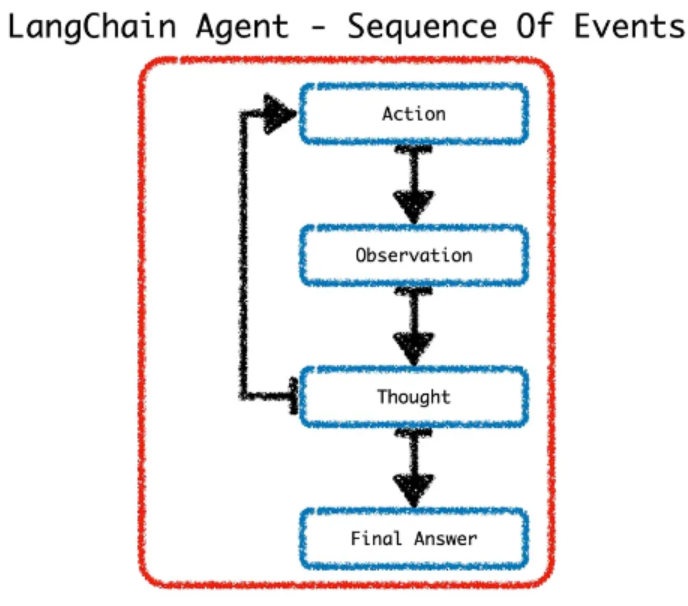

A Tool Calling Agent refers to an AI system of framework that dynamically invokes external tools or APIs to accomplish tasks as part of its decision-making process. Instead of relying solely on internal reasoning or knowledge, the agent calls specific tools to perform actions like calculations, searches, or other operations. This type of agent is often used in real-world applications where tasks require interaction with external systems.

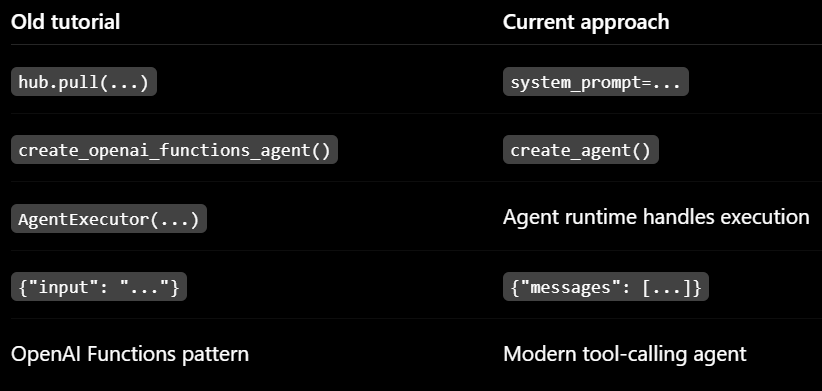


**What is agent_scratchpad?**

Think of it as the agent's working area / temporary memory during one execution.

It stores the intermediate steps the agent has taken, such as:

`Thought → Tool Call → Tool Result → Thought → Final Answer`

For example, your question:

`What is the length of "hello" and what is 2 × 3?`

The agent may internally go through:

```
User Question
      ↓
Agent thinks
      ↓
Call get_word_length("hello")
      ↓
Tool returns 5
      ↓
Agent thinks again
      ↓
Call multiply(2, 3)
      ↓
Tool returns 6
      ↓
Agent generates final answer

```

The intermediate information is represented through the **agent scratchpad**.

In [38]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain.agents import create_agent


In [39]:
# LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

In [40]:
# Embeddings Model
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

In [41]:
# Load ageye documentation
loader = WebBaseLoader(
    "https://ageyetech.com/automation#ra-equipment"
)

docs = loader.load()


In [42]:
# Split Documents
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

documents = splitter.split_documents(docs)

In [43]:
# Create FAISS vectorstore
vectorstore = FAISS.from_documents(
    documents,
    embeddings
)

In [44]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

In [36]:
results = retriever.invoke(
    "How to Automated Tray Washer?"
)

print("\n========== RETRIEVER TEST ==========\n")

print(results[0].page_content)



========== RETRIEVER TEST ==========

workflow through Digital Cultivation and AGEYE controls. No middleware. No manual coordination.        Transplanting fromthe nursery     Lift back to primarygrow racks     Tray Handling& Stacking     Cup Loadinginto trays     Tray Reassembly             Equipment The full equipment lineup         01 Automated Seeder Precision seeding at scale. Handles multiple seed types and tray configurations with consistent placement accuracy, eliminating the variability and labor cost of manual seeding. Integrated with crop scheduling so seeding runs are auto-triggered based on the production plan.   Consistent seed placement across tray formats  Multi-seed-type capability  Triggered automatically from crop schedule  Reduces seeding labor by up to 90%           02 Automated Transplanter Moves seedlings from nursery trays to grow positions with minimal plant stress and zero manual handling. Synchronized with growth stage transitions defined in crop recipes, so 

In [45]:
@tool
def ra_equipment_search(query: str) -> str:
    """
    Search the automation RA-equipment documentation.

    Use this tool whenever the user asks about automated workflow,
    full equipment lineup, Automated Seeder, Automated Transplanter,
    Automated Harvester, Automated Tray Washer, or AGEYE ARIS
    related functionality.
    """

    docs = retriever.invoke(query)

    return "\n\n".join(
        doc.page_content
        for doc in docs
    )

In [46]:
search_tool = TavilySearch(
    max_results=5
)

In [47]:
tools = [
    search_tool,
    ra_equipment_search
]

In [50]:
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="""
    You are a helpful assistant.

    For questions related to RA equipment, automated workflow,
    Automated Seeder, Automated Transplanter, Automated Harvester,
    Automated Tray Washer, or AGEYE ARIS, use the
    ra_equipment_search tool.

    For current external information, use web search.

    Answer only using reliable information from the available tools.
    Be concise and accurate.
    """
)


In [51]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What equipment is available in the automated RA equipment lineup?"
        }
    ]
})

print(result["messages"][-1].content)

c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\ve

[{'type': 'text', 'text': 'The automated AGEYE / RA equipment lineup consists of eight integrated systems designed for end-to-end workflow automation:\n\n1. **Automated Seeder**  \n   Precision seeding at scale handling multiple seed types and tray configurations, auto-triggered from the crop schedule.\n\n2. **Automated Transplanter**  \n   Gently moves seedlings from nursery trays to grow positions with minimal plant stress, synchronized with crop recipe growth stages.\n\n3. **Automated Material Handling**  \n   Handles tray moving, stacking, and positioning between all automation stations (from seeding to nursery, grow racks, harvest, and tray washing).\n\n4. **Automated Harvester**  \n   Delivers consistent, rapid harvesting tailored to commercial vertical farming crop types and tray formats.\n\n5. **Automated Root Cutter**  \n   Provides clean, precision root removal at harvest-line speed to improve product uniformity for packaging and reduce waste.\n\n6. **Automated Tray Washer** 

In [52]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What equipment is available in the automated RA equipment lineup?"
        }
    ]
})

print(result["messages"][-1].text)

c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\ve

The automated RA equipment lineup includes the following equipment:

1. **Automated Seeder:** Provides precision seeding at scale, supporting multiple seed types and tray configurations with automated scheduling.
2. **Automated Transplanter:** Moves seedlings from nursery trays to grow positions with minimal plant stress and zero manual handling.
3. **Automated Material Handling:** Handles tray movement, stacking, and positioning across all automation stations (seeder, nursery, grow racks, harvest, wash).
4. **Automated Harvester:** Delivers rapid, consistent harvesting tailored to commercial vertical farming crop types and tray formats.
5. **Automated Root Cutter:** Performs precision root removal at line speed for product uniformity and reduced waste.
6. **Automated Tray Washer:** Cleans and sanitizes grow trays between cycles and feeds them directly back to the seeding workflow.
7. **Packaging Machine:** Handles automated weighing, portioning, and sealing into retail-ready or foodse

In [53]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "whats the weather in new york city?"
        }
    ]
})

print(result["messages"][-1].text)

c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\rootl\OneDrive\Documents\euron\YT\sunny_savita\end-to-end-langGraph\venv\lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Currently in **New York City**:

* **Temperature:** ~75°F to 80°F (24°C to 27°C)
* **Conditions:** Mostly sunny / fair
* **Humidity:** ~44% – 62%
* **Wind:** Light, around 3–8 mph
* **High/Low Today:** Expected high around 78°F–80°F (26°C), with a low around 68°F–71°F (20°C).
